In [8]:
# Ячейка 1: импорты и настройки

# базовые библиотеки
import pandas as pd
import numpy as np

# визуализация
import matplotlib.pyplot as plt
import seaborn as sns

# настройки pandas
pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 120)

# настройки seaborn / matplotlib
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

In [9]:
# Ячейка 2: загрузка данных
path = "../data/raw/diabetic_data_DSMED.csv"
df = pd.read_csv(path)

In [10]:
# Ячейка 3: первые строки и размеры
display(df.head(5))
print("Shape:", df.shape)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,diag_1,diag_2,diag_3,number_diagnoses,max_glu_serum,A1Cresult,metformin,repaglinide,nateglinide,chlorpropamide,glimepiride,acetohexamide,glipizide,glyburide,tolbutamide,pioglitazone,rosiglitazone,acarbose,miglitol,troglitazone,tolazamide,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,?,Pediatrics-Endocrinology,41,0,1,0,0,0,250.83,?,?,1,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,?,?,59,0,18,0,0,0,276,250.01,255,9,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,?,?,11,5,13,2,0,1,648,250,V27,6,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,?,?,44,1,16,0,0,0,8,250.43,403,7,NaN,NaN,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,?,?,51,0,8,0,0,0,197,157,250,5,NaN,NaN,No,No,No,No,No,No,Steady,No,No,No,No,No,No,No,No,No,No,Steady,No,No,No,No,No,Ch,Yes,NO


Shape: (101766, 50)


In [11]:
# Ячейка 4: информация о типах
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [12]:
# Ячейка 5: поиск “?” в каждом столбце
missing_q = {col: (df[col] == '?').sum() for col in df.columns}
# Оставим только те, где есть “?”
missing_q = {k:v for k,v in missing_q.items() if v>0}
missing_q

{'race': np.int64(2273),
 'weight': np.int64(98569),
 'payer_code': np.int64(40256),
 'medical_specialty': np.int64(49949),
 'diag_1': np.int64(21),
 'diag_2': np.int64(358),
 'diag_3': np.int64(1423)}

In [13]:
# Ячейка 6: привести '?' к настоящим пропускам и посчитать долю

df.replace('?', np.nan, inplace=True)

# Процент пропусков по колонкам
missing_perc = df.isna().mean().mul(100).round(2)
display(missing_perc[missing_perc>0])

race                  2.23
weight               96.86
payer_code           39.56
medical_specialty    49.08
diag_1                0.02
diag_2                0.35
diag_3                1.40
max_glu_serum        94.75
A1Cresult            83.28
dtype: float64

In [14]:
#Ячейка 7:

# 1. Удаляем признаки с >80% пропусков
to_drop = ['weight', 'max_glu_serum', 'A1Cresult']
df.drop(columns=to_drop, inplace=True)

# 2. Приводим все '?' к NaN (еще раз на всякий случай)
df.replace('?', np.nan, inplace=True)

# 3. Заполняем NaN в категориальных столбцах
fill_unknown = ['race', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
for col in fill_unknown:
    df[col].fillna('Unknown', inplace=True)

# 4. Проверяем, что пропусков больше нет
print("Осталось пропусков:", df.isna().sum().sum())

Осталось пропусков: 0


C:\Users\Admin\AppData\Local\Temp\ipykernel_20376\2999863499.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna('Unknown', inplace=True)


Counts:
 readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64 

Проценты:
 readmitted
NO     53.91
>30    34.93
<30    11.16
Name: count, dtype: float64 %



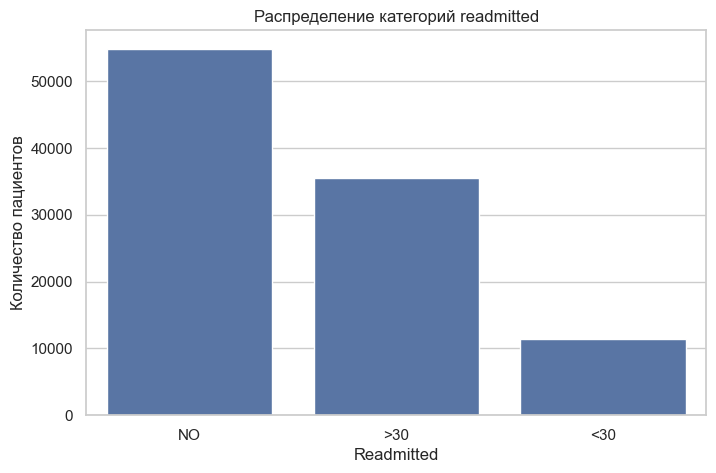

In [15]:
# Ячейка 8: Распределение повторных госпитализаций

# Выводим числовую разбивку по категориям
counts = df['readmitted'].value_counts()
print("Counts:\n", counts, "\n")
print("Проценты:\n", (counts / len(df) * 100).round(2), "%\n")

# Визуализация
sns.countplot(x='readmitted', data=df, order=counts.index)
plt.title("Распределение категорий readmitted")
plt.xlabel("Readmitted")
plt.ylabel("Количество пациентов")
plt.show()

## Распределение категорий повторной госпитализации

- Около 54 % пациентов не возвращаются в стационар  
- Примерно 35 % возвращаются позже 30 дней  
- Лишь около 11 % возвращаются в течение 30 дней  

---

## Выводы и рекомендации

Класс пациентов, возвращающихся в течение 30 дней (`<30`), сильно менее представлен. При обучении модели это может привести к тому, что алгоритм «забудет» про этот малочисленный класс.

**Возможные подходы:**

1. **Бинаризация задачи**  
   Объединить категории `NO` и `>30` в класс «нецелевой» и рассматривать `<30` как «целевой». Тогда доля позитивного класса составит примерно 11 %, что упрощает балансировку выборки.

2. **Многоклассовая классификация**  
   Оставить все три категории, но при обучении использовать  
   - `class_weight` в моделях,  
   - методы выборки (SMOTE, undersampling) для выравнивания частот.

**Рекомендации по метрикам:**

- При бинарной задаче → **Precision/Recall** или **ROC AUC** для класса `<30`.  
- При мультклассовой задаче → **macro-averaged F1-score** или **balanced accuracy**.
